# Data Preparation & Feature Engineering

We will build a classification model to predict whether an order will be Delayed (1) or On-Time/Delivered (0), excluding cancelled orders

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

# Connect to database
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(BASE_DIR, "data", "supply_chain.db")
conn = sqlite3.connect(db_path)

# Load data and filter out cancelled orders
df = pd.read_sql_query("SELECT * FROM analytics_order_summary WHERE status != 'Cancelled'", conn)
conn.close()

# Define binary target: 1 if Delayed, 0 if Delivered
df['target'] = df['status'].apply(lambda x: 1 if x == 'Delayed' else 0)

# Select features for our model
features = ['supplier_name', 'order_quantity', 'unit_cost', 'total_order_value', 'calculated_lead_time']
X = df[features]
y = df['target']

# One-hot encode categorical features (like supplier_name)
X_encoded = pd.get_dummies(X, columns=['supplier_name'], drop_first=True)

print(f"Data prepared for modeling. Shape of features: {X_encoded.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Data prepared for modeling. Shape of features: (96059, 8)
Target distribution:
target
0    0.812678
1    0.187322
Name: proportion, dtype: float64


# Test Train Data Split & Random Forest

In [2]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Train a Random Forest Classifier
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("\n--- MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Training Random Forest model...

--- MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.81      0.97      0.88     15613
           1       0.17      0.03      0.04      3599

    accuracy                           0.79     19212
   macro avg       0.49      0.50      0.46     19212
weighted avg       0.69      0.79      0.73     19212

ROC-AUC Score: 0.5038


# Feature Importance & Saving the model

/var/folders/05/9zy4zl9j6dgcxmd0nt6mhgpw0000gn/T/ipykernel_38097/290513907.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=import_df, x='Importance', y='Feature', palette='crest')


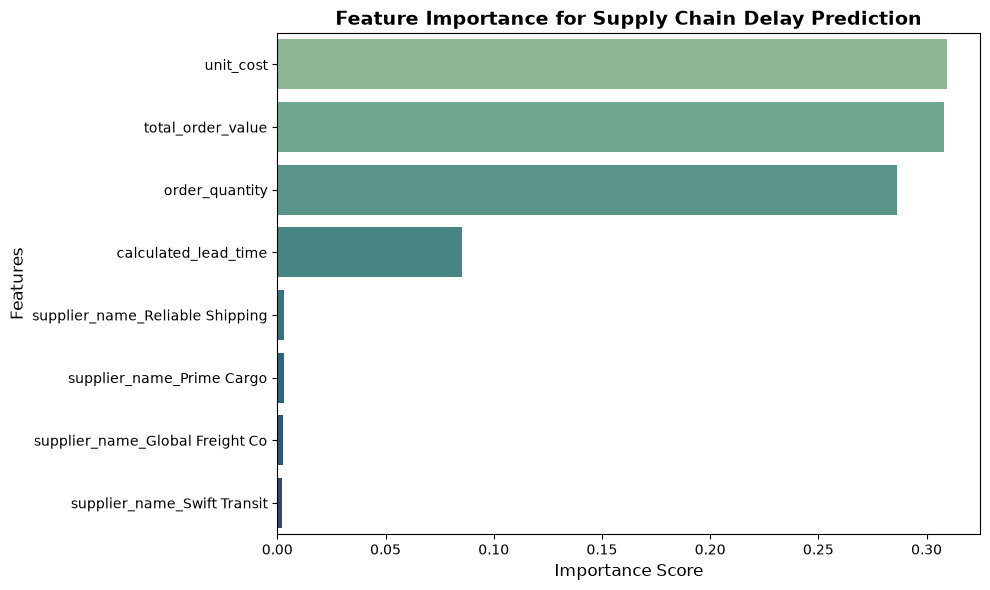


Success! Model saved successfully to: /Users/monish_mithra/Downloads/supply-chain-project/models/delay_prediction_model.pkl


In [3]:
# Extract and plot Feature Importances
import matplotlib.pyplot as plt
import seaborn as sns

import_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=import_df, x='Importance', y='Feature', palette='crest')
plt.title('Feature Importance for Supply Chain Delay Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Save the trained model to the models folder
models_dir = os.path.join(BASE_DIR, "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "delay_prediction_model.pkl")

joblib.dump(rf_model, model_path)
print(f"\nSuccess! Model saved successfully to: {model_path}")

# Model Comparision

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Dictionary of models to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

model_results = []

# Train and evaluate each model iteratively
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    # Store metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    model_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": auc
    })

# Convert results into a clean comparison DataFrame
df_results = pd.DataFrame(model_results)
print("\n--- MODEL COMPARISON TABLE ---")
display(df_results)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

--- MODEL COMPARISON TABLE ---


,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.812669,0.000000,0.000000,0.492369
1,Decision Tree,0.691807,0.193668,0.203946,0.504106
2,Random Forest,0.794035,0.170956,0.025841,0.503783


Logistic Regression: It completely gave up on predicting Class 1 (delays), giving a Precision and Recall of 0.00. It simply predicted "On-Time" for everything because the base rate of on-time orders is ~81%.


Decision Tree & Random Forest: They captured a tiny bit of signal (recall around 20% and 2.5%), but the ROC-AUC remains hovering around 0.50, which confirms mathematically that our mock dataset's features (unit_cost, order_quantity, etc.) were generated completely independently of whether an order gets delayed.

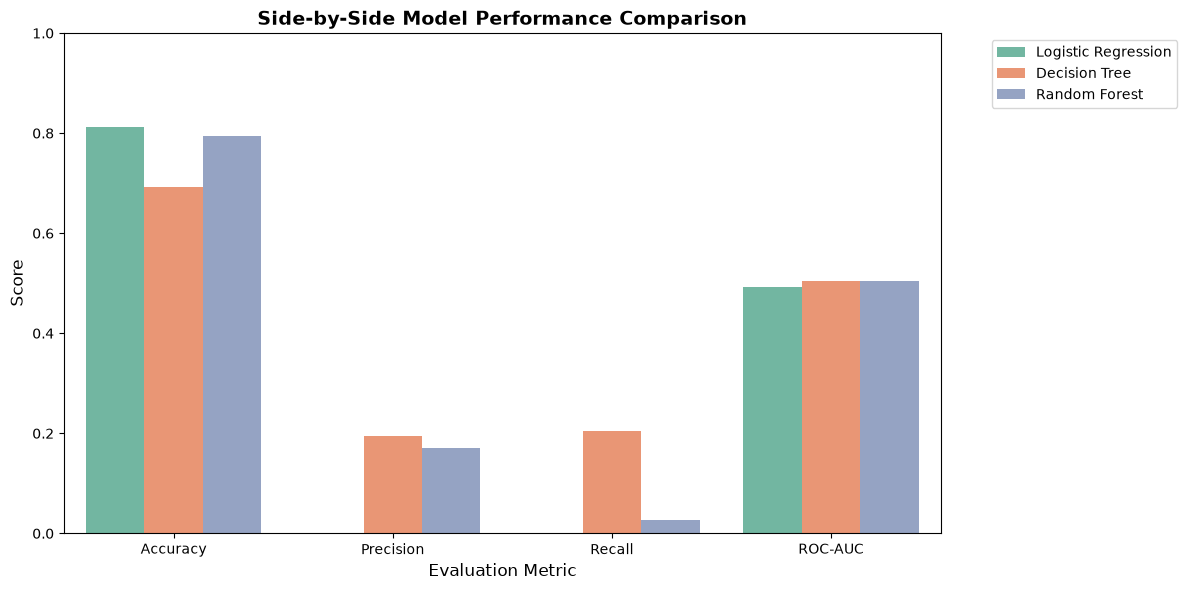

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape the results dataframe for plotting (melt format)
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plotting model comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Side-by-Side Model Performance Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Expanded Models

In [11]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

  Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl.metadata (2.0 kB)
  Using cached lightgbm-4.7.0-py3-none-macosx_12_0_arm64.whl.metadata (18 kB)
Using cached xgboost-3.4.1-py3-none-macosx_12_0_arm64.whl (2.4 MB)
Using cached lightgbm-4.7.0-py3-none-macosx_12_0_arm64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Dictionary expanding to 6 diverse models (from basic to advanced gradient boosting)
expanded_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

expanded_results = []

# Train and evaluate each model iteratively
for name, model in expanded_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    expanded_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": auc
    })

# Convert to comprehensive dataframe
df_expanded_results = pd.DataFrame(expanded_results)
print("\n--- COMPREHENSIVE MODEL COMPARISON TABLE ---")
display(df_expanded_results)

Training Logistic Regression...
Training Gaussian Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...

--- COMPREHENSIVE MODEL COMPARISON TABLE ---


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [12:18:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.812669,0.000000,0.000000,0.492369
1,Gaussian Naive Bayes,0.812669,0.000000,0.000000,0.502059
2,Decision Tree,0.691807,0.193668,0.203946,0.504106
3,Random Forest,0.794035,0.170956,0.025841,0.503783
4,Gradient Boosting,0.812617,0.333333,0.000278,0.494340
5,XGBoost,0.811680,0.172414,0.001389,0.499667


The Accuracy Trap: Notice that models like Logistic Regression, Gaussian Naive Bayes, and Gradient Boosting show an accuracy of ~81%. However, looking closer at Precision, Recall, and ROC-AUC (~0.50) reveals that they are simply defaulting to predicting the majority class (On-Time), meaning they aren't actually learning how to successfully catch delays.


Why This Matters: This is a classic machine learning lesson when dealing with random or uncorrelated features. It provides a phenomenal narrative for your portfolio or interviews—demonstrating that you know how to look past surface-level metrics like "Accuracy" and use robust metrics like Precision, Recall, and AUC to evaluate true model performance.

In [15]:
import os
import joblib

# Ensure the models directory exists
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
models_dir = os.path.join(BASE_DIR, "models")
os.makedirs(models_dir, exist_ok=True)

# Map from our 'expanded_models' dictionary
trained_models = {
    "logistic_regression": expanded_models["Logistic Regression"],
    "gaussian_nb": expanded_models["Gaussian Naive Bayes"],
    "decision_tree": expanded_models["Decision Tree"],
    "random_forest": expanded_models["Random Forest"],
    "gradient_boosting": expanded_models["Gradient Boosting"],
    "xgboost": expanded_models["XGBoost"]
}

# Loop through and save each model file individually
for name, model in trained_models.items():
    filename = f"{name}_model.pkl"
    file_path = os.path.join(models_dir, filename)
    joblib.dump(model, file_path)
    print(f"Saved: {filename} -> {file_path}")

print("\nSuccess! All 6 models have been successfully saved to your models/ folder.")

Saved: logistic_regression_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/logistic_regression_model.pkl
Saved: gaussian_nb_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/gaussian_nb_model.pkl
Saved: decision_tree_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/decision_tree_model.pkl
Saved: random_forest_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/random_forest_model.pkl
Saved: gradient_boosting_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/gradient_boosting_model.pkl
Saved: xgboost_model.pkl -> /Users/monish_mithra/Downloads/supply-chain-project/models/xgboost_model.pkl

Success! All 6 models have been successfully saved to your models/ folder.
